10.Data Visualization III

Download the Iris flower dataset or any other dataset into a DataFrame. (e.g.,
https://archive.ics.uci.edu/ml/datasets/Iris ). Scan the dataset and give the inference as:

1.List down the features and their types (e.g., numeric, nominal) available in the dataset.

2.Create a histogram for each feature in the dataset to illustrate the feature distributions.

3.Create a boxplot for each feature in the dataset.

4.Compare distributions and identify outliers.

In [2]:
# Cell 1: Import necessary libraries
# This cell imports all required libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Cell 2: Load and display the dataset
# This cell loads the Iris dataset and displays basic information about it
# Load the Iris dataset
df = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')

In [4]:
# Display the first few rows to understand the structure
print("First 5 rows of the dataset:")
print(df.head())

# Get basic information about the dataset
print("\nBasic information about the dataset:")
print(df.info())

# Get statistical summary of the data
print("\nStatistical summary of the dataset:")
print(df.describe())

First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical summary of the dataset:
       sepal_length  sepal_width  petal_length  pe

In [5]:
# Cell 3: List features and their types
# This cell identifies and displays the features and their data types
print("\n1. Features and their types:")
feature_types = pd.DataFrame({
    'Feature': df.columns,
    'Type': ['numeric' if pd.api.types.is_numeric_dtype(df[col]) else 'nominal' for col in df.columns]
})
print(feature_types)


1. Features and their types:
        Feature     Type
0  sepal_length  numeric
1   sepal_width  numeric
2  petal_length  numeric
3   petal_width  numeric
4       species  nominal



2. Creating histograms for feature distributions...


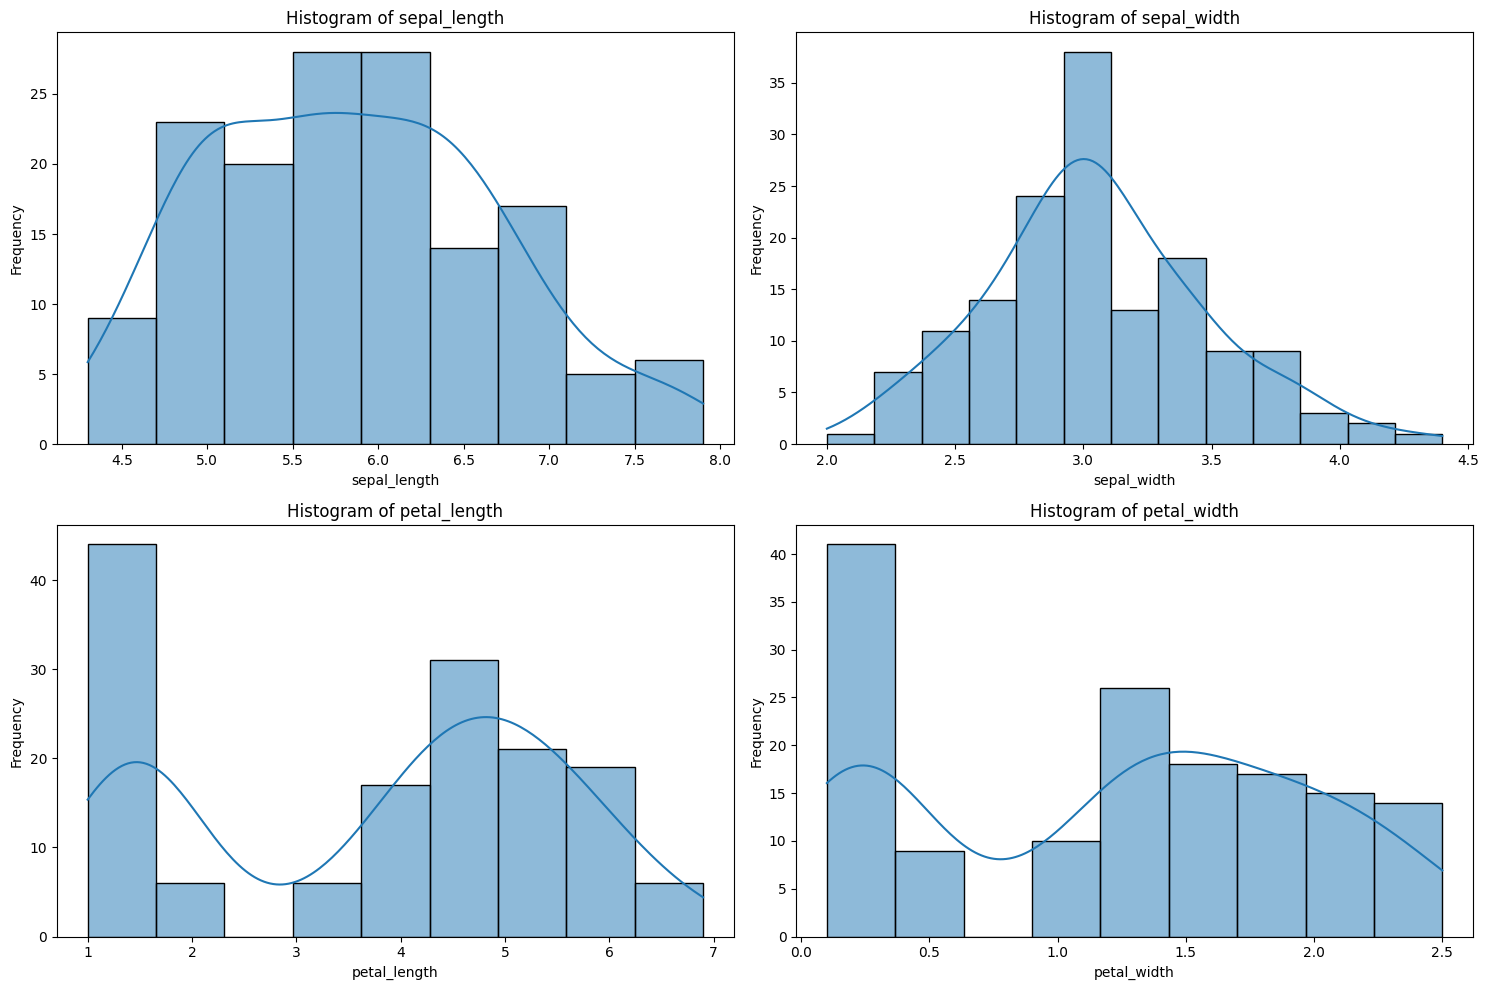

In [6]:
# Cell 4: Create histograms for each feature
# This cell creates histograms to visualize the distribution of each numeric feature
print("\n2. Creating histograms for feature distributions...")

# Identify numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set up the figure size for histograms
plt.figure(figsize=(15, 10))

# Create a histogram for each numeric feature
for i, feature in enumerate(numeric_columns):
    plt.subplot(2, len(numeric_columns)//2 + len(numeric_columns)%2, i+1)
    # Add a histogram with KDE plot for better visualization
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_histograms.png')
plt.show()


3. Creating boxplots for each feature...


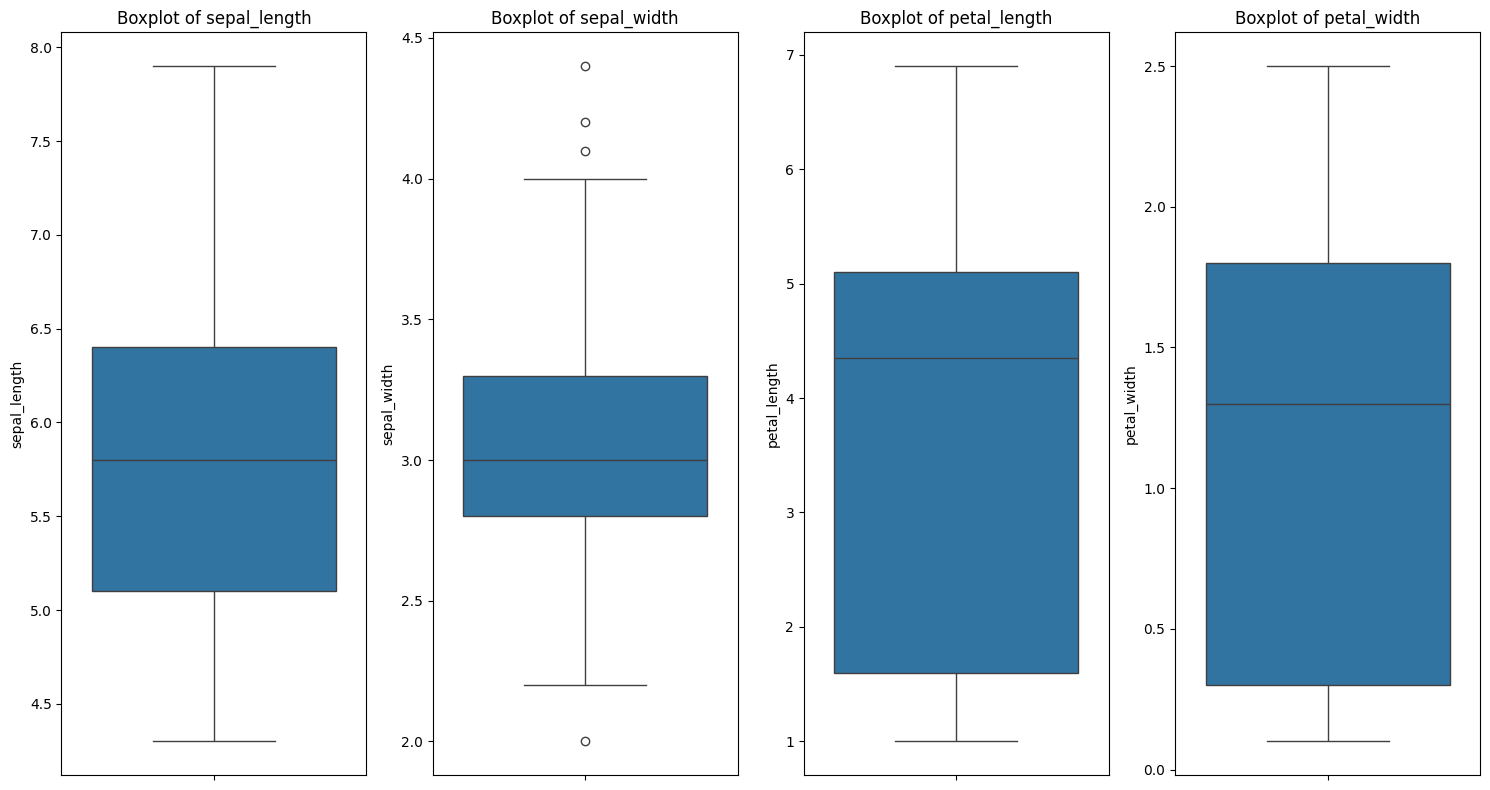

In [7]:
# Cell 5: Create boxplots for each feature
# This cell creates boxplots to visualize the distribution and identify potential outliers
print("\n3. Creating boxplots for each feature...")

plt.figure(figsize=(15, 8))

# Create a boxplot for each numeric feature
for i, feature in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig('feature_boxplots.png')
plt.show()

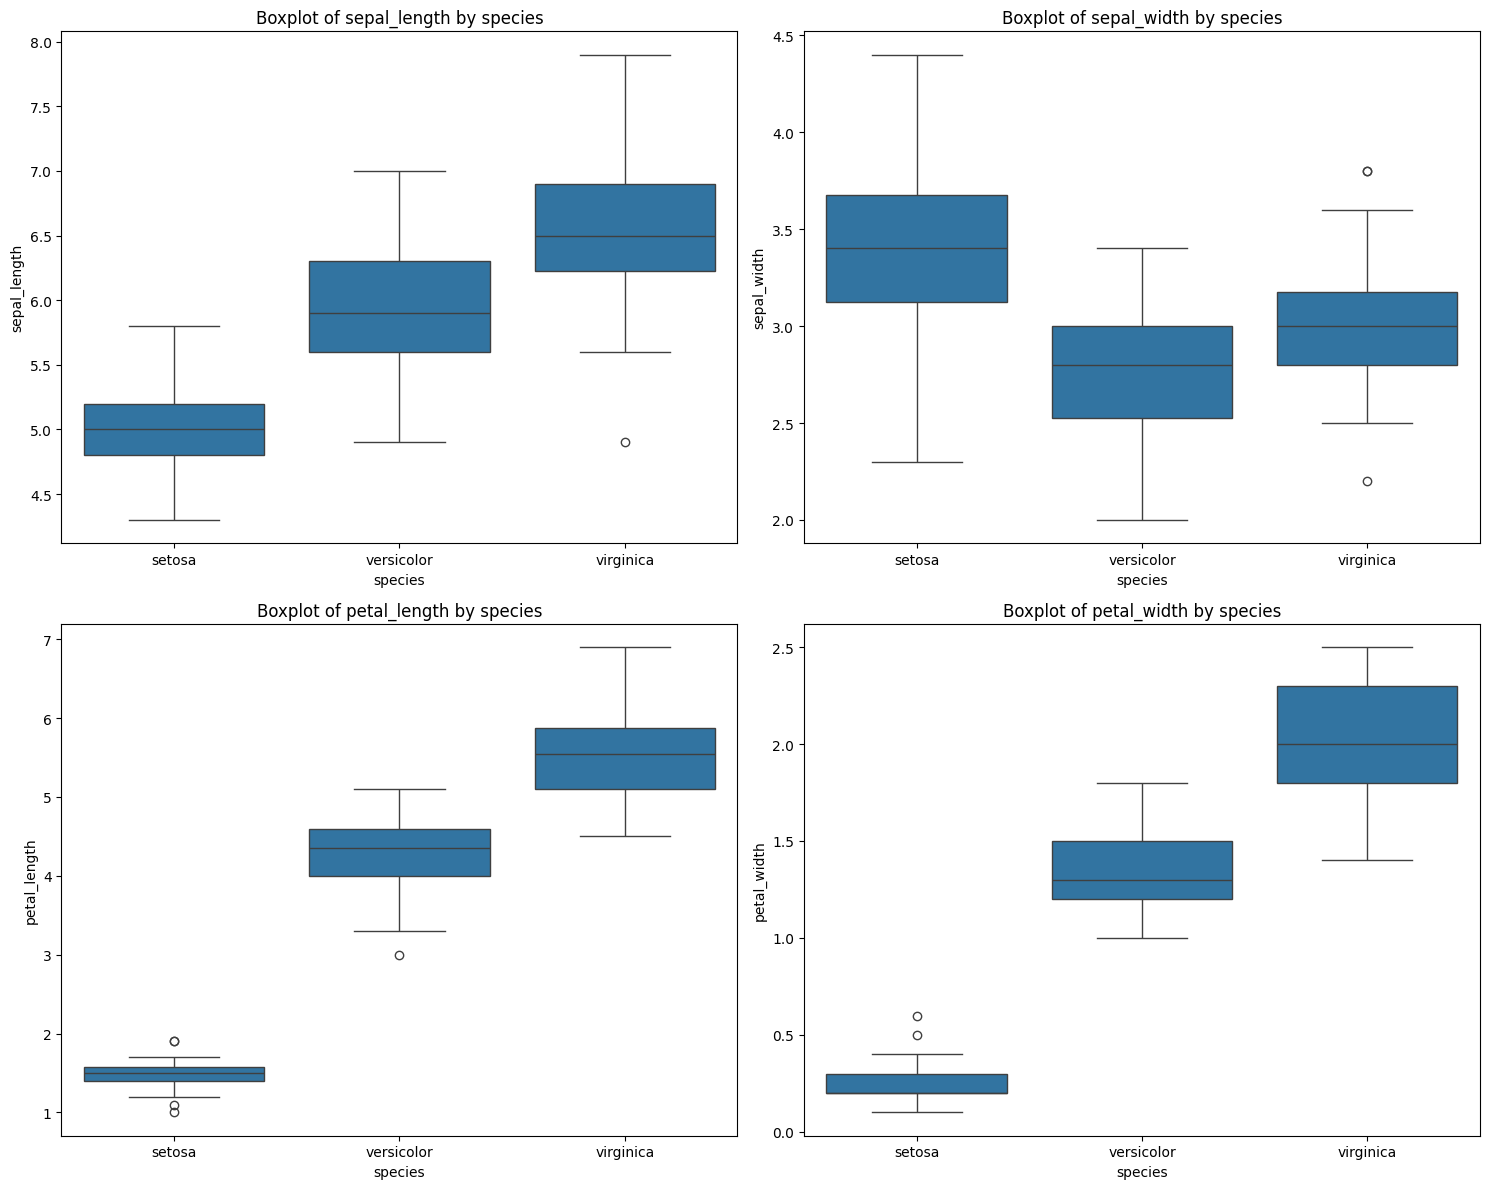

In [9]:
# Cell 6: Create class-grouped boxplots
# This cell creates boxplots grouped by class for each numeric feature
# Identifying the class column
class_column = df.columns[-1]

# Create boxplots grouped by class if class column is categorical
if not pd.api.types.is_numeric_dtype(df[class_column]):
    plt.figure(figsize=(15, 12))
    for i, feature in enumerate(numeric_columns):
        plt.subplot(2, len(numeric_columns)//2 + len(numeric_columns)%2, i+1)
        sns.boxplot(x=df[class_column], y=df[feature])
        plt.title(f'Boxplot of {feature} by {class_column}')
        plt.xlabel(class_column)
        plt.ylabel(feature)
    
    plt.tight_layout()
    plt.savefig('feature_boxplots_by_class.png')
    plt.show()

In [10]:
# Cell 7: Identify and analyze outliers
# This cell identifies outliers using the IQR method and summarizes findings
print("\n4. Comparing distributions and identifying outliers...")

# Function to identify outliers using IQR method
def find_outliers_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

# Find outliers for each numeric feature
outliers_summary = {}
for feature in numeric_columns:
    outliers = find_outliers_iqr(df[feature])
    outliers_summary[feature] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(df)) * 100,
        'min': outliers.min() if len(outliers) > 0 else None,
        'max': outliers.max() if len(outliers) > 0 else None
    }

# Display outlier information
print("\nOutlier Summary:")
for feature, info in outliers_summary.items():
    print(f"{feature}:")
    print(f"  Number of outliers: {info['count']}")
    print(f"  Percentage of outliers: {info['percentage']:.2f}%")
    if info['count'] > 0:
        print(f"  Range: {info['min']} to {info['max']}")
    print()


4. Comparing distributions and identifying outliers...

Outlier Summary:
sepal_length:
  Number of outliers: 0
  Percentage of outliers: 0.00%

sepal_width:
  Number of outliers: 4
  Percentage of outliers: 2.67%
  Range: 2.0 to 4.4

petal_length:
  Number of outliers: 0
  Percentage of outliers: 0.00%

petal_width:
  Number of outliers: 0
  Percentage of outliers: 0.00%



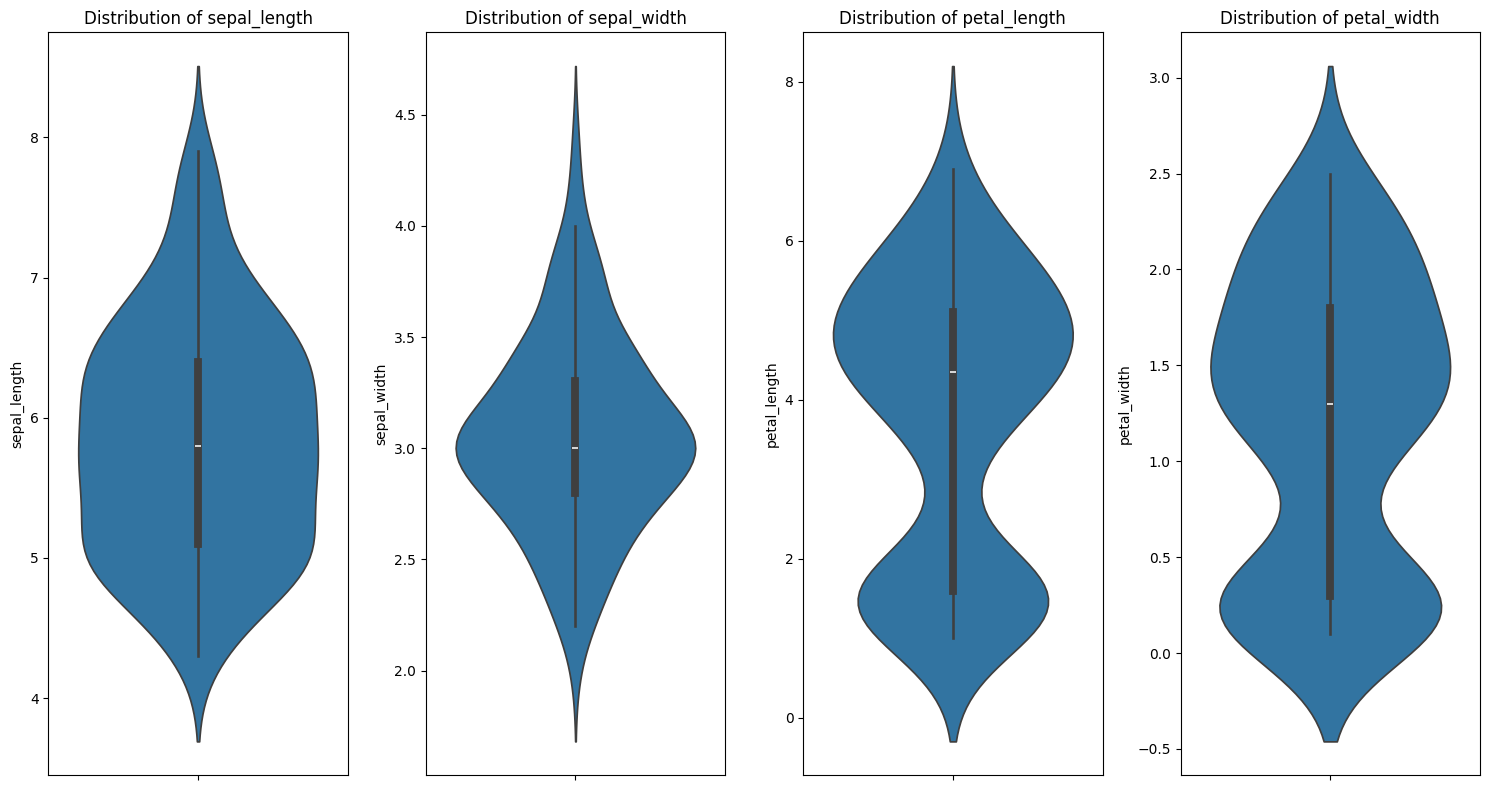

In [11]:
# Cell 8: Feature distribution comparison using violin plots
# This cell creates violin plots to better visualize the distributions
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i+1)
    sns.violinplot(y=df[feature])
    plt.title(f'Distribution of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig('feature_violin_plots.png')
plt.show()

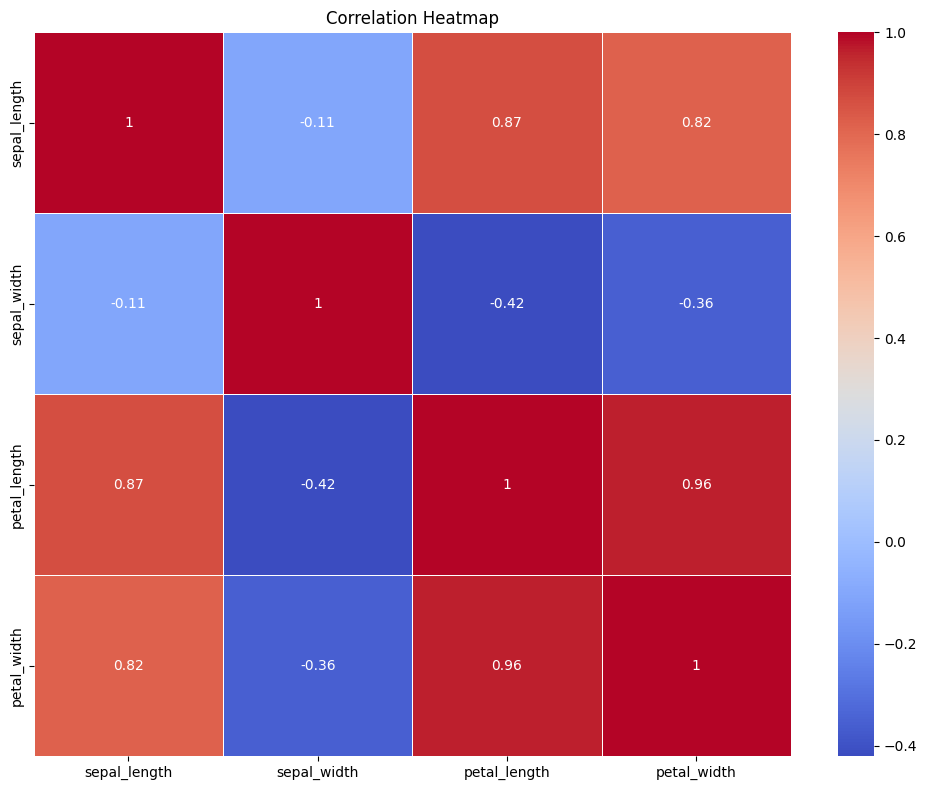

In [12]:
# Cell 9: Correlation heatmap
# This cell creates a correlation heatmap to show relationships between features
if len(numeric_columns) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_columns].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()


In [13]:
# Cell 10: Distribution comparison summary
# This cell summarizes distribution characteristics for each feature
print("\nDistribution Comparison Summary:")
for feature in numeric_columns:
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    skew_val = df[feature].skew()
    
    print(f"{feature}:")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Skewness: {skew_val:.2f}")
    
    if skew_val > 0.5:
        print("  Distribution is right-skewed")
    elif skew_val < -0.5:
        print("  Distribution is left-skewed")
    else:
        print("  Distribution is approximately symmetric")
    print()



Distribution Comparison Summary:
sepal_length:
  Mean: 5.84
  Median: 5.80
  Skewness: 0.31
  Distribution is approximately symmetric

sepal_width:
  Mean: 3.05
  Median: 3.00
  Skewness: 0.33
  Distribution is approximately symmetric

petal_length:
  Mean: 3.76
  Median: 4.35
  Skewness: -0.27
  Distribution is approximately symmetric

petal_width:
  Mean: 1.20
  Median: 1.30
  Skewness: -0.10
  Distribution is approximately symmetric




5. Creating pie charts for class distribution...


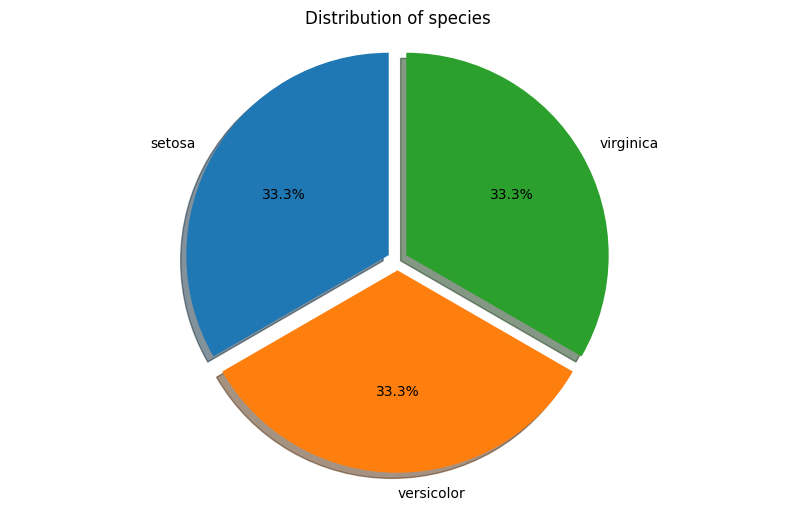

In [14]:
# Cell 11: Class distribution pie chart
# This cell creates a pie chart showing the distribution of classes
print("\n5. Creating pie charts for class distribution...")

if not pd.api.types.is_numeric_dtype(df[class_column]):
    # Create a pie chart for class distribution
    plt.figure(figsize=(10, 6))
    class_counts = df[class_column].value_counts()
    plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            startangle=90, shadow=True, explode=[0.05] * len(class_counts))
    plt.title(f'Distribution of {class_column}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.savefig('class_distribution_pie.png')
    plt.show()

<Figure size 1500x1500 with 0 Axes>

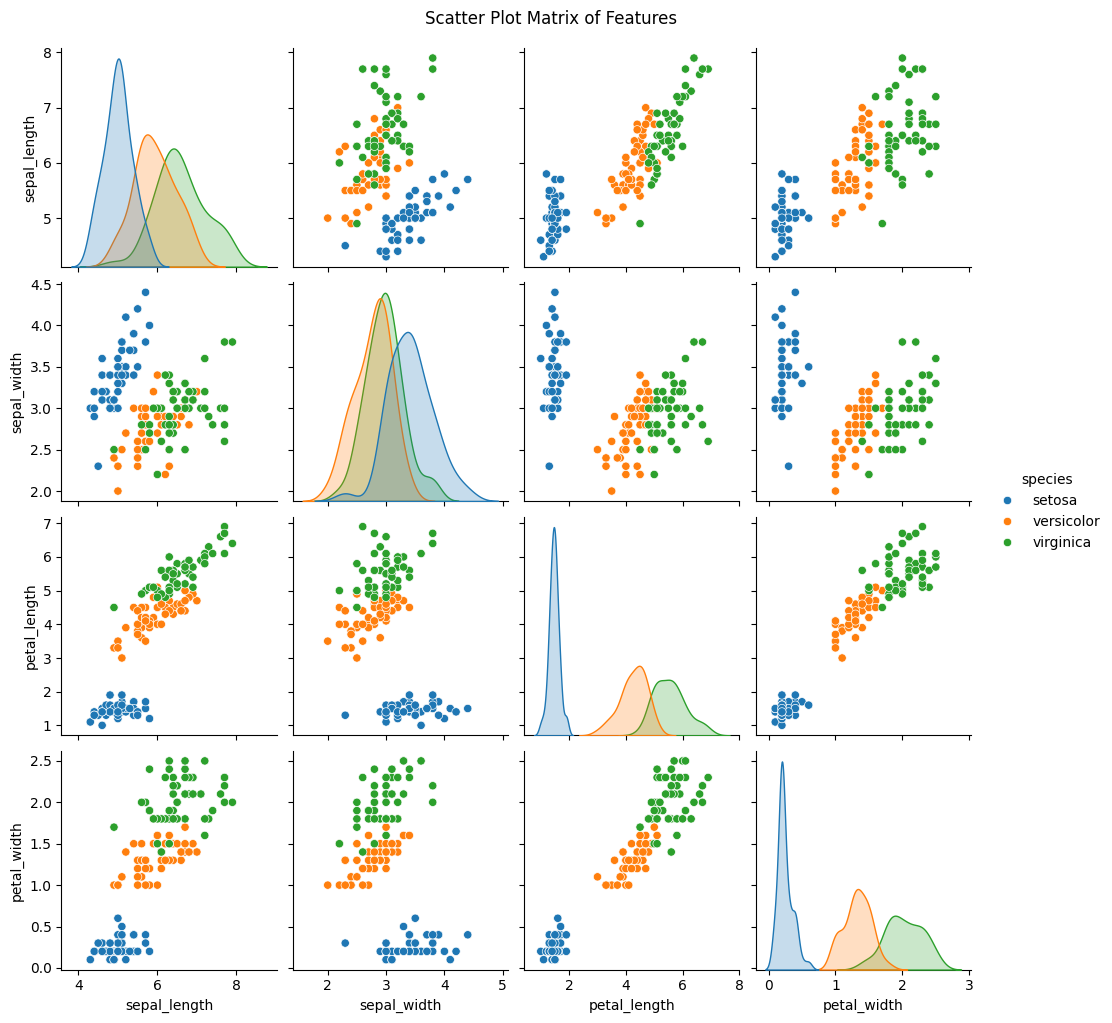

In [15]:
# Cell 12: Scatter plot matrix
# This cell creates a matrix of scatter plots to visualize relationships between features
plt.figure(figsize=(15, 15))
sns.pairplot(df, hue=class_column if not pd.api.types.is_numeric_dtype(df[class_column]) else None)
plt.suptitle('Scatter Plot Matrix of Features', y=1.02)
plt.savefig('scatter_plot_matrix.png')
plt.show()

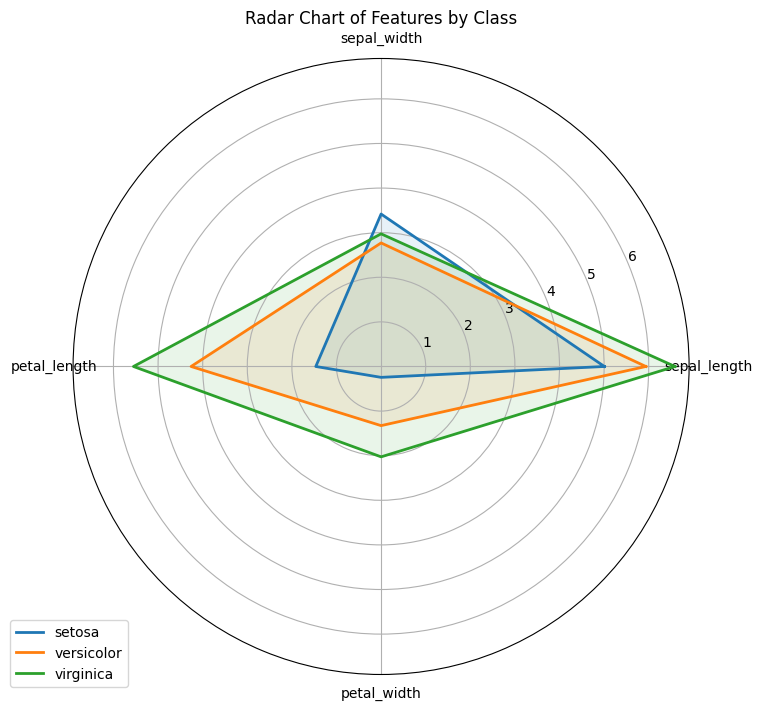

In [16]:
# Cell 13: Radar/Spider chart
# This cell creates a radar chart to compare feature values across classes
if not pd.api.types.is_numeric_dtype(df[class_column]):
    # Calculate mean values for each numeric feature by class
    class_means = df.groupby(class_column)[numeric_columns].mean()
    
    # Create radar chart
    plt.figure(figsize=(10, 8))
    
    # Set up the angles for each feature
    num_features = len(numeric_columns)
    angles = np.linspace(0, 2*np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon
    
    # Set up the plot
    ax = plt.subplot(111, polar=True)
    
    # Plot each class
    for class_name in class_means.index:
        values = class_means.loc[class_name].values.tolist()
        values += values[:1]  # Close the polygon
        ax.plot(angles, values, linewidth=2, label=class_name)
        ax.fill(angles, values, alpha=0.1)
    
    # Set feature labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(numeric_columns)
    
    # Add legend and title
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Radar Chart of Features by Class')
    plt.savefig('radar_chart.png')
    plt.show()

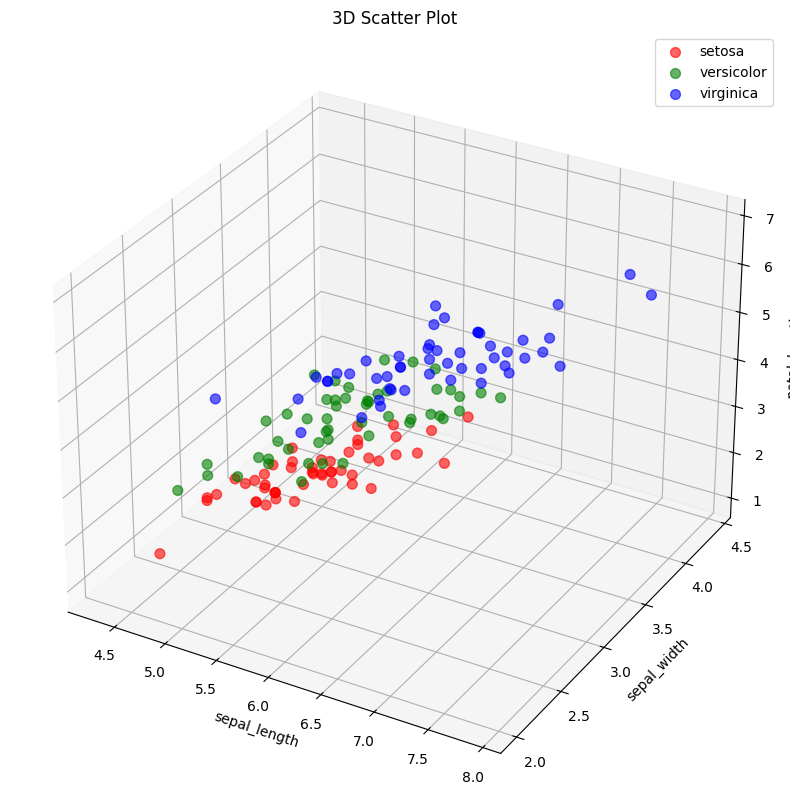

In [17]:
# Cell 14: 3D scatter plot
# This cell creates a 3D scatter plot to visualize three features at once
if len(numeric_columns) >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    if not pd.api.types.is_numeric_dtype(df[class_column]):
        # Get unique classes
        classes = df[class_column].unique()
        colors = ['r', 'g', 'b', 'c', 'm', 'y']  # Add more colors if needed
        
        # Plot points for each class
        for i, cls in enumerate(classes):
            cls_data = df[df[class_column] == cls]
            ax.scatter(
                cls_data[numeric_columns[0]], 
                cls_data[numeric_columns[1]], 
                cls_data[numeric_columns[2]], 
                c=colors[i % len(colors)], 
                label=cls,
                s=50,
                alpha=0.6
            )
    else:
        # If no class column, plot all points with the same color
        ax.scatter(
            df[numeric_columns[0]], 
            df[numeric_columns[1]], 
            df[numeric_columns[2]], 
            c='b', 
            s=50,
            alpha=0.6
        )
    
    ax.set_xlabel(numeric_columns[0])
    ax.set_ylabel(numeric_columns[1])
    ax.set_zlabel(numeric_columns[2])
    plt.title('3D Scatter Plot')
    plt.legend()
    plt.savefig('3d_scatter_plot.png')
    plt.show()

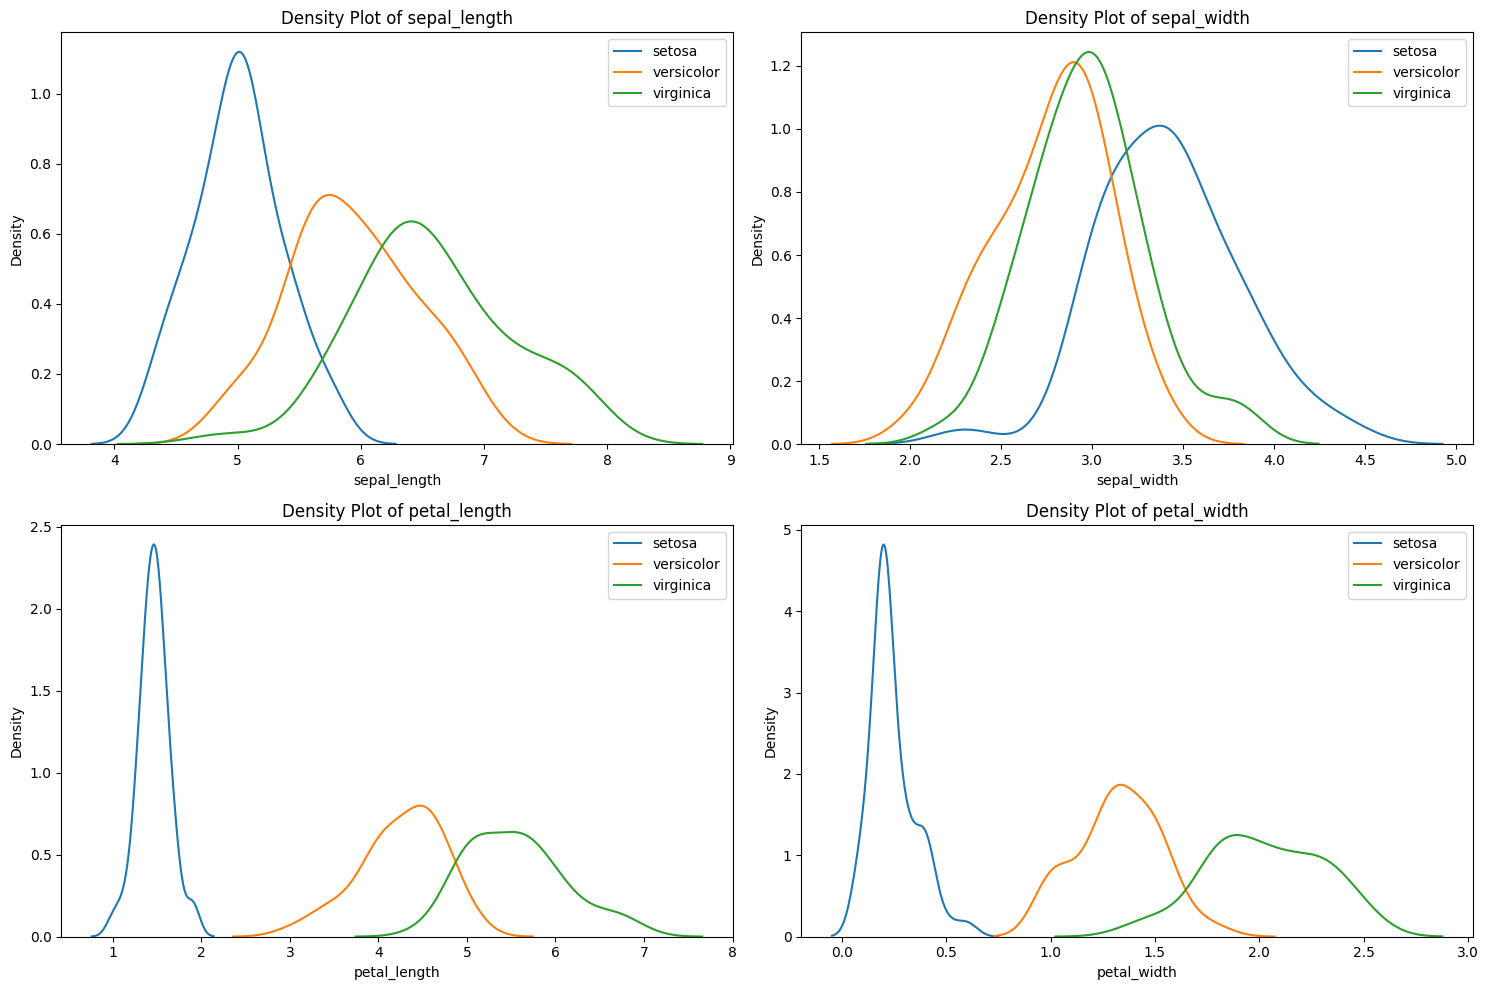

In [18]:
# Cell 15: Density plots
# This cell creates density plots to visualize distributions by class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_columns):
    plt.subplot(2, len(numeric_columns)//2 + len(numeric_columns)%2, i+1)
    
    if not pd.api.types.is_numeric_dtype(df[class_column]):
        # Plot density for each class
        for cls in df[class_column].unique():
            sns.kdeplot(df[df[class_column] == cls][feature], label=cls)
        plt.legend()
    else:
        # Plot overall density
        sns.kdeplot(df[feature])
    
    plt.title(f'Density Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.savefig('density_plots.png')
plt.show()

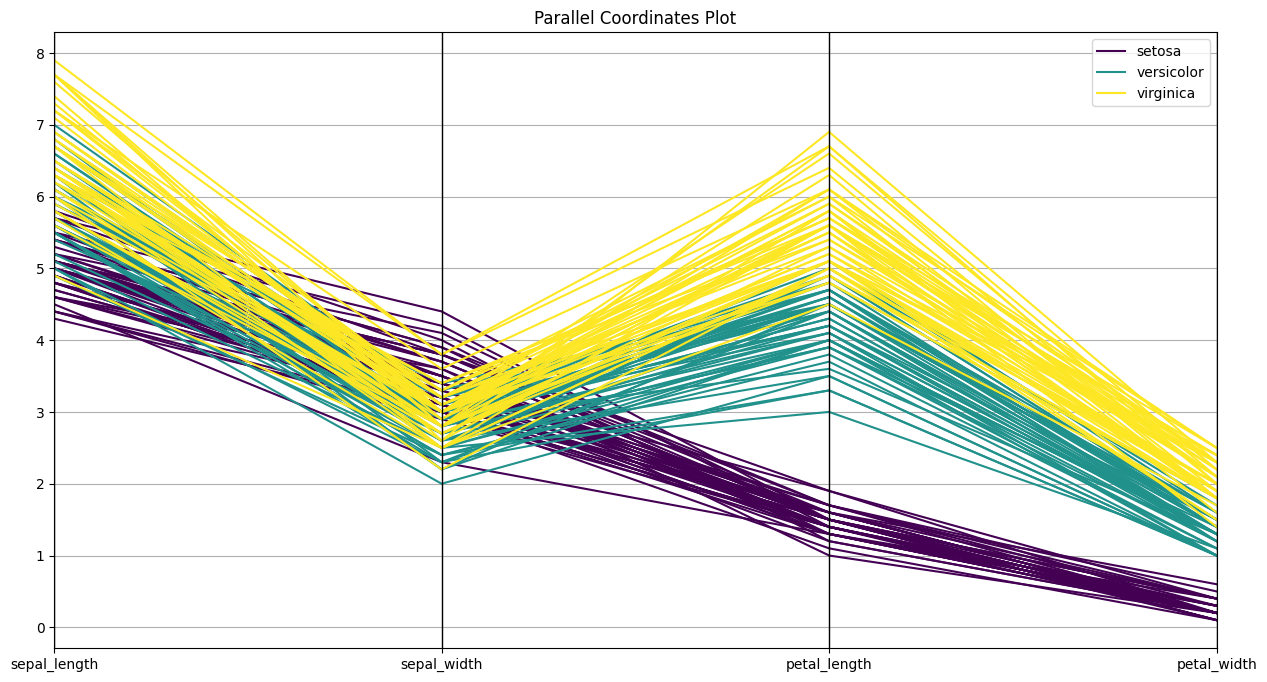

In [19]:
# Cell 16: Parallel coordinates plot
# This cell creates a parallel coordinates plot to visualize multivariate data
plt.figure(figsize=(15, 8))
pd.plotting.parallel_coordinates(
    df,
    class_column if not pd.api.types.is_numeric_dtype(df[class_column]) else numeric_columns[0],
    colormap='viridis'
)
plt.title('Parallel Coordinates Plot')
plt.grid(True)
plt.savefig('parallel_coordinates.png')
plt.show()

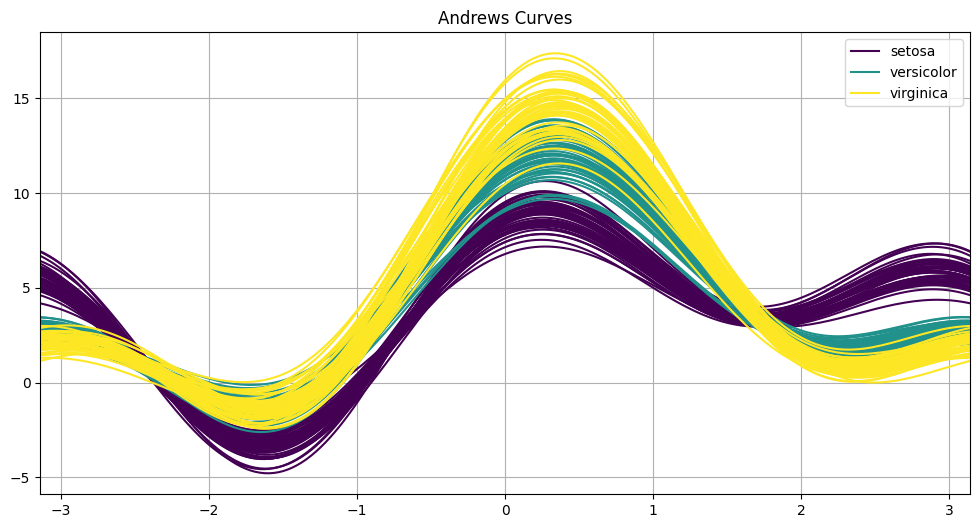

In [20]:
# Cell 17: Andrews curves
# This cell creates Andrews curves to visualize multivariate data by class
plt.figure(figsize=(12, 6))
pd.plotting.andrews_curves(
    df,
    class_column if not pd.api.types.is_numeric_dtype(df[class_column]) else numeric_columns[0],
    colormap='viridis'
)
plt.title('Andrews Curves')
plt.grid(True)
plt.savefig('andrews_curves.png')
plt.show()


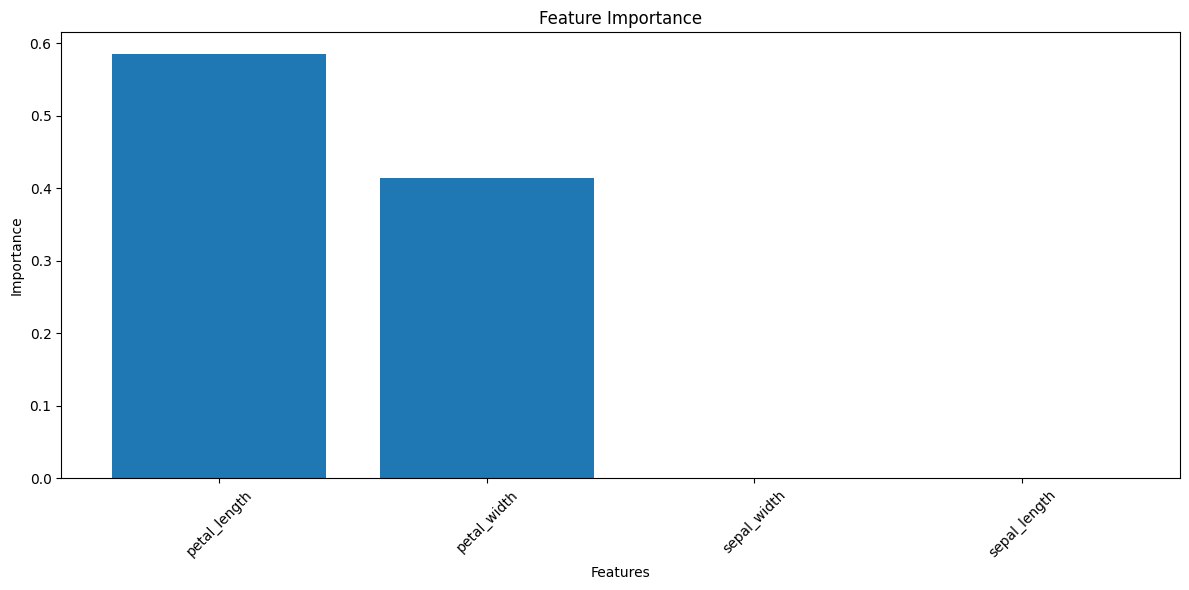


Feature Importance:
petal_length: 0.5856
petal_width: 0.4144
sepal_width: 0.0000
sepal_length: 0.0000


In [21]:
# Cell 18: Feature importance visualization
# This cell creates a bar chart of feature importances using a decision tree
if not pd.api.types.is_numeric_dtype(df[class_column]):
    from sklearn.tree import DecisionTreeClassifier
    
    # Prepare features and target
    X = df[numeric_columns]
    y = df[class_column]
    
    # Create and fit a simple decision tree
    tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree_model.fit(X, y)
    
    # Get feature importances
    importances = tree_model.feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    sorted_features = [numeric_columns[i] for i in indices]
    sorted_importances = importances[indices]
    
    # Create bar chart of feature importances
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sorted_importances)), sorted_importances)
    plt.xticks(range(len(sorted_importances)), sorted_features, rotation=45)
    plt.title('Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    print("\nFeature Importance:")
    for i, feature in enumerate(sorted_features):
        print(f"{feature}: {sorted_importances[i]:.4f}")


6. Creating line charts for sorted feature values...


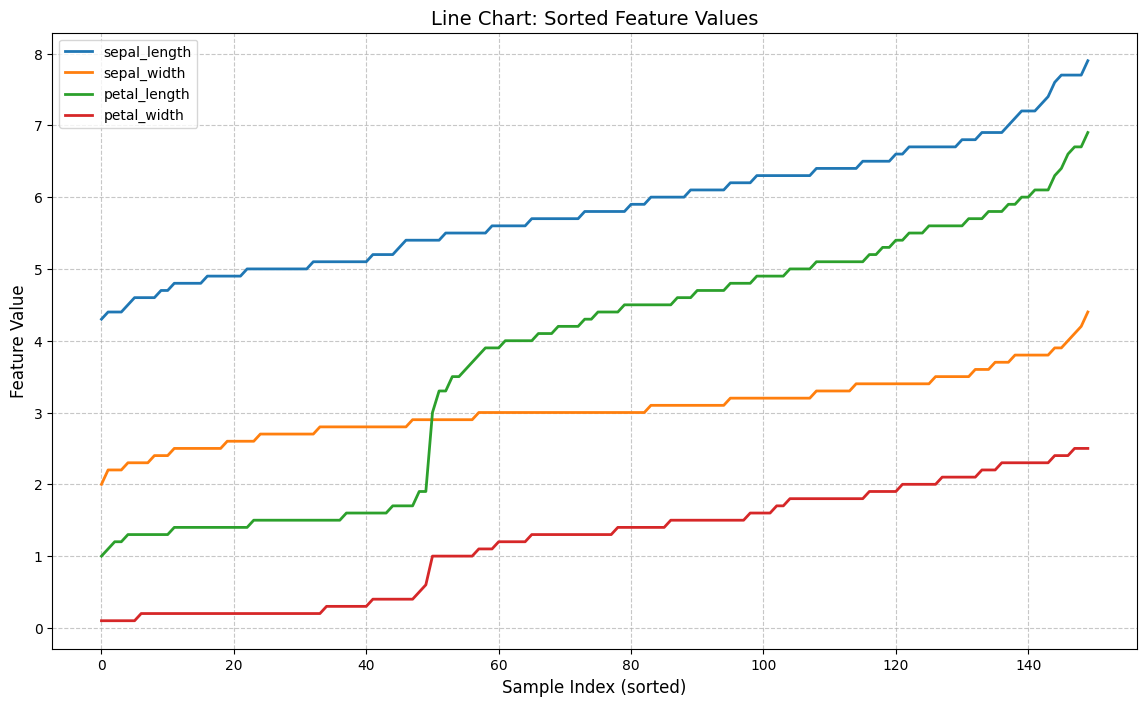

In [22]:
# Cell 19: Line charts
# This cell creates line charts for visualizing trends in the data
print("\n6. Creating line charts for sorted feature values...")

# Line chart: Compare feature values across sorted samples
plt.figure(figsize=(14, 8))
for feature in numeric_columns:
    # Sort the values to create a smoother line
    sorted_values = df[feature].sort_values().values
    plt.plot(range(len(sorted_values)), sorted_values, linewidth=2, label=feature)

plt.title('Line Chart: Sorted Feature Values', fontsize=14)
plt.xlabel('Sample Index (sorted)', fontsize=12)
plt.ylabel('Feature Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('line_chart_sorted_features.png')
plt.show()

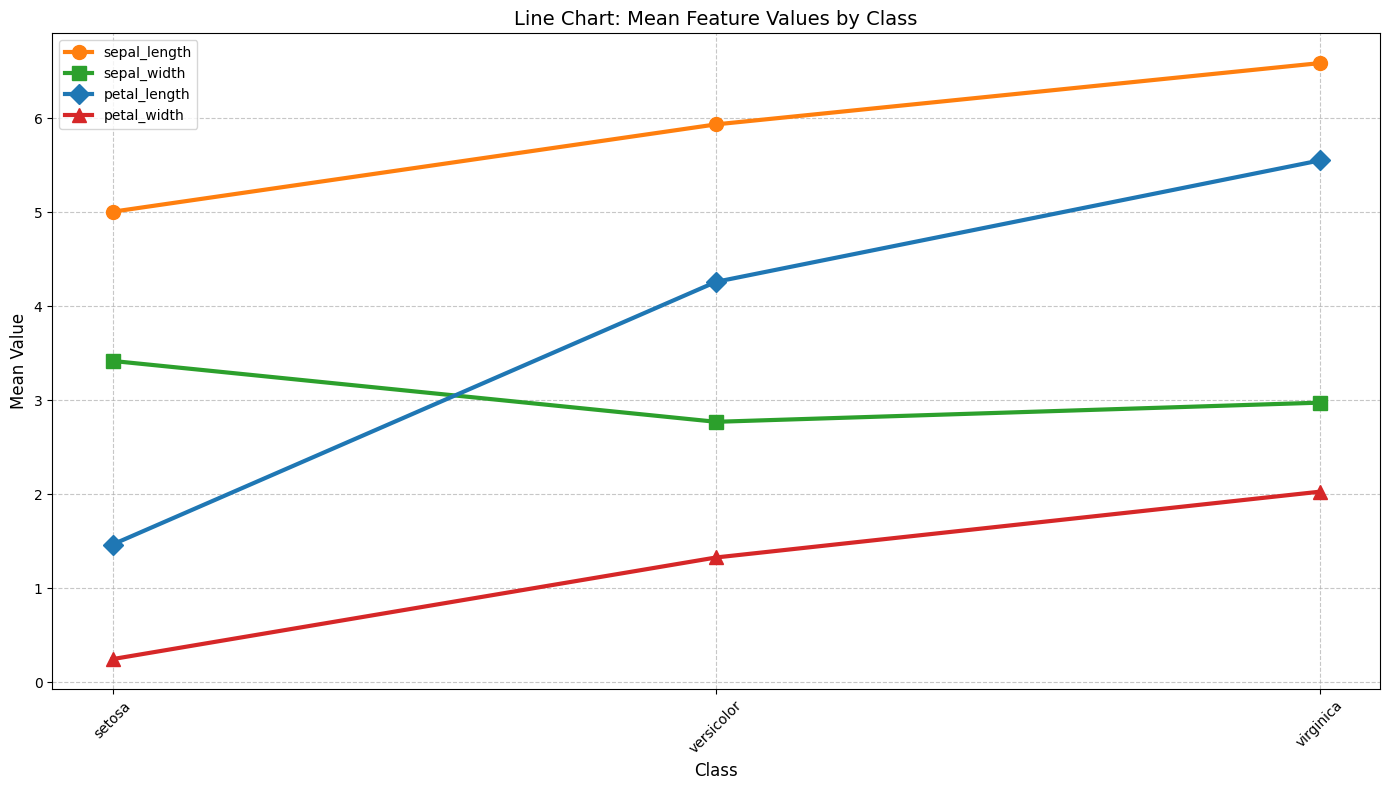

In [23]:
# Cell 20: Feature means across classes with custom colors and markers
if not pd.api.types.is_numeric_dtype(df[class_column]):
    # Calculate mean values for each feature by class
    class_means = df.groupby(class_column)[numeric_columns].mean().reset_index()
    
    # Create line chart with custom colors, markers, and line styles
    plt.figure(figsize=(14, 8))
    
    # Set different markers and colors for different features
    markers = ['o', 's', 'D', '^', 'v', 'p', '*']
    colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728', '#9467bd', '#8c564b']
    
    for i, feature in enumerate(numeric_columns):
        plt.plot(class_means[class_column], class_means[feature], 
                 marker=markers[i % len(markers)], 
                 color=colors[i % len(colors)],
                 linewidth=3, 
                 markersize=10,
                 label=feature)
    
    plt.title('Line Chart: Mean Feature Values by Class', fontsize=14)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Mean Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('line_chart_class_means.png')
    plt.show()

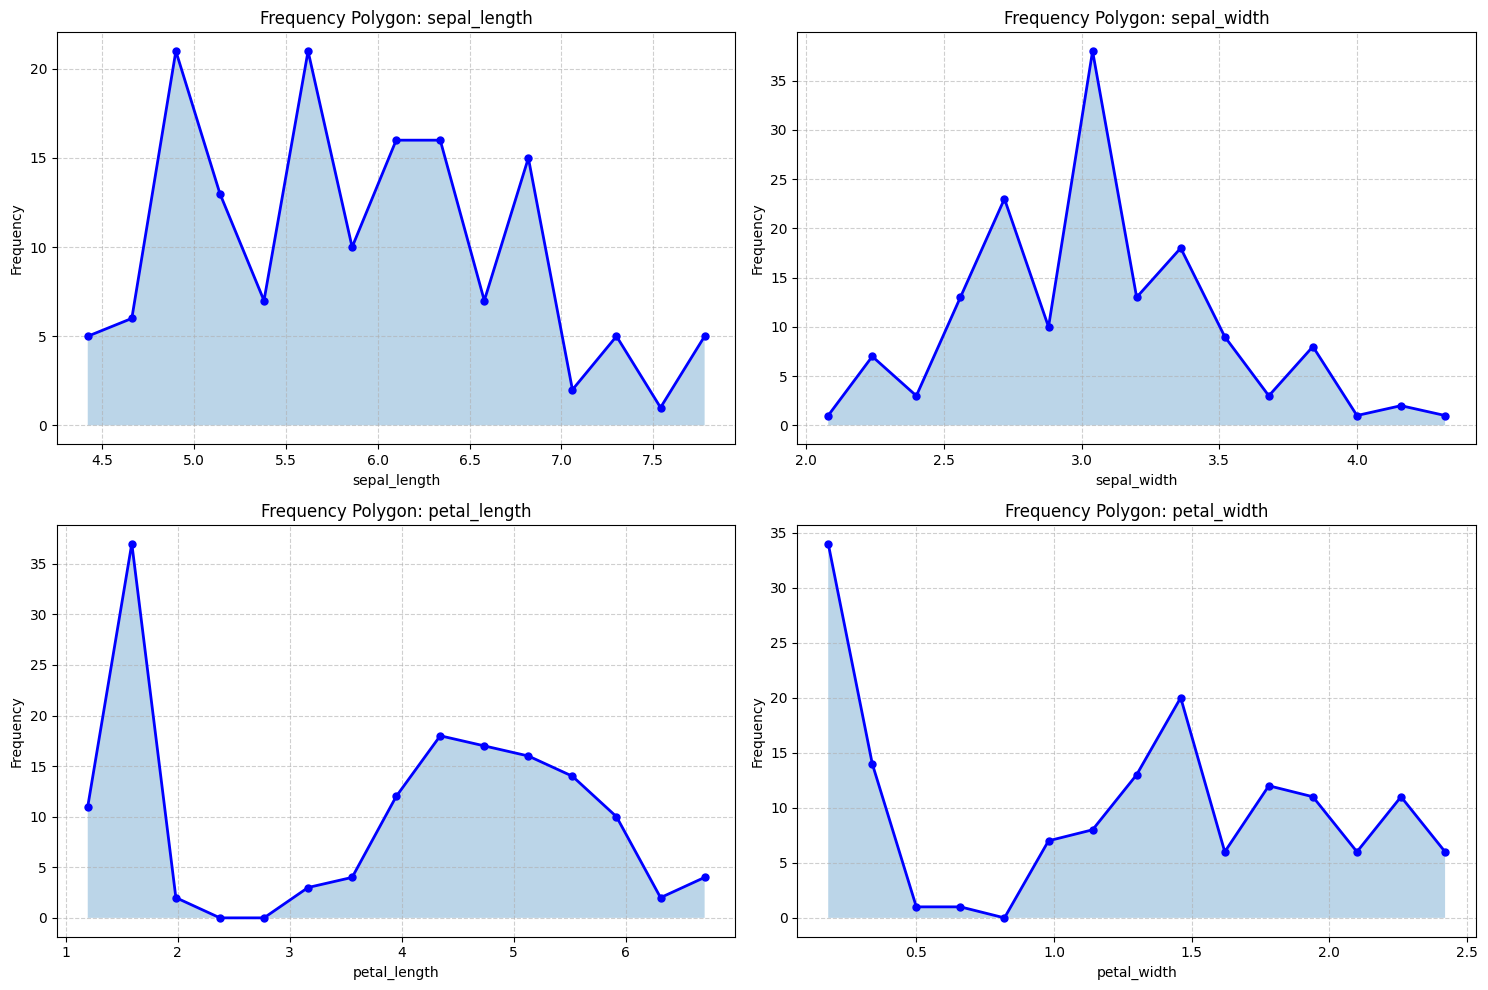

In [24]:
# Cell 21: Frequency polygons
# This cell creates frequency polygons to visualize distributions
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_columns):
    plt.subplot(2, len(numeric_columns)//2 + len(numeric_columns)%2, i+1)
    
    # Calculate the bin edges for the histogram
    hist, bin_edges = np.histogram(df[feature], bins=15)
    
    # Calculate the bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot the frequency polygon
    plt.plot(bin_centers, hist, 'b-', linewidth=2, marker='o', markersize=5)
    plt.fill_between(bin_centers, hist, alpha=0.3)
    
    plt.title(f'Frequency Polygon: {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('frequency_polygons_individual.png')
plt.show()

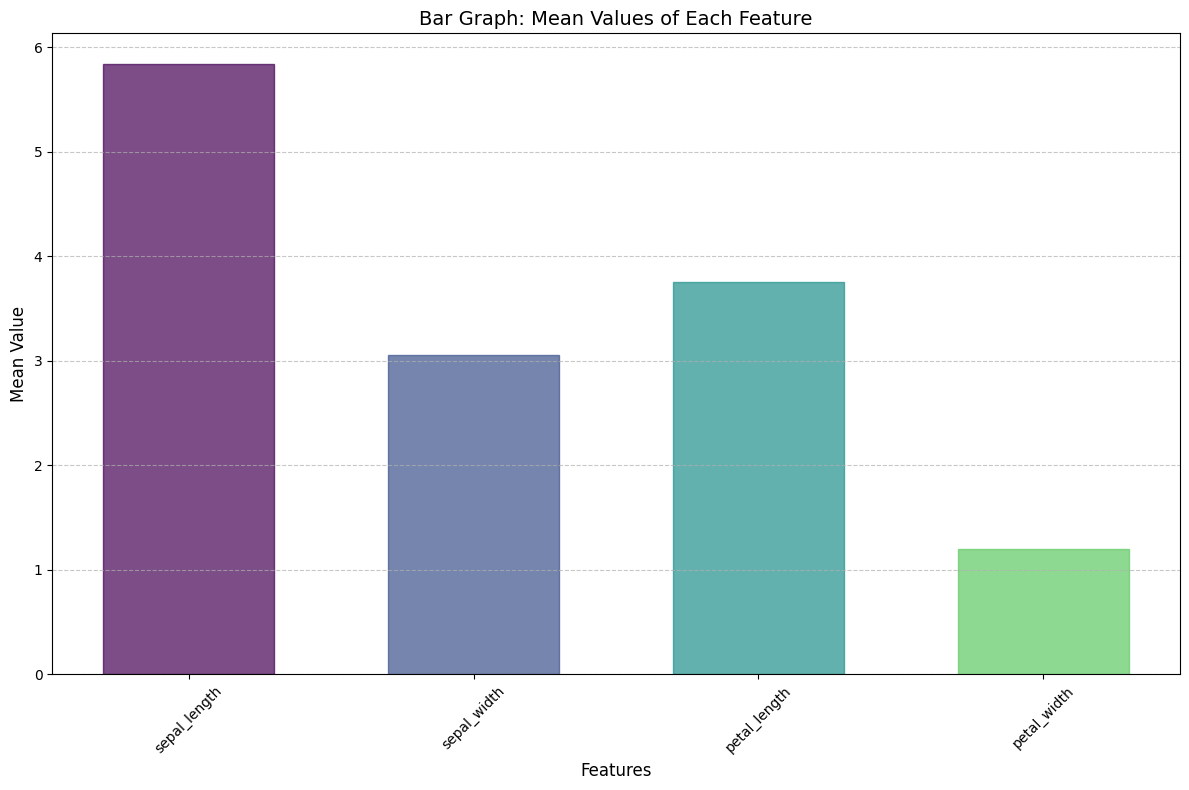

In [25]:
# Cell 22: Bar graphs of mean values
# This cell creates bar graphs to compare mean values across features
plt.figure(figsize=(12, 8))
mean_values = df[numeric_columns].mean()

# Create vertical bar chart with custom colors
bars = plt.bar(range(len(mean_values)), mean_values, width=0.6, alpha=0.7)

# Use different colors for each bar
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.viridis(i / len(mean_values)))

plt.title('Bar Graph: Mean Values of Each Feature', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean Value', fontsize=12)
plt.xticks(range(len(mean_values)), mean_values.index, rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bar_graph_vertical.png')
plt.show()

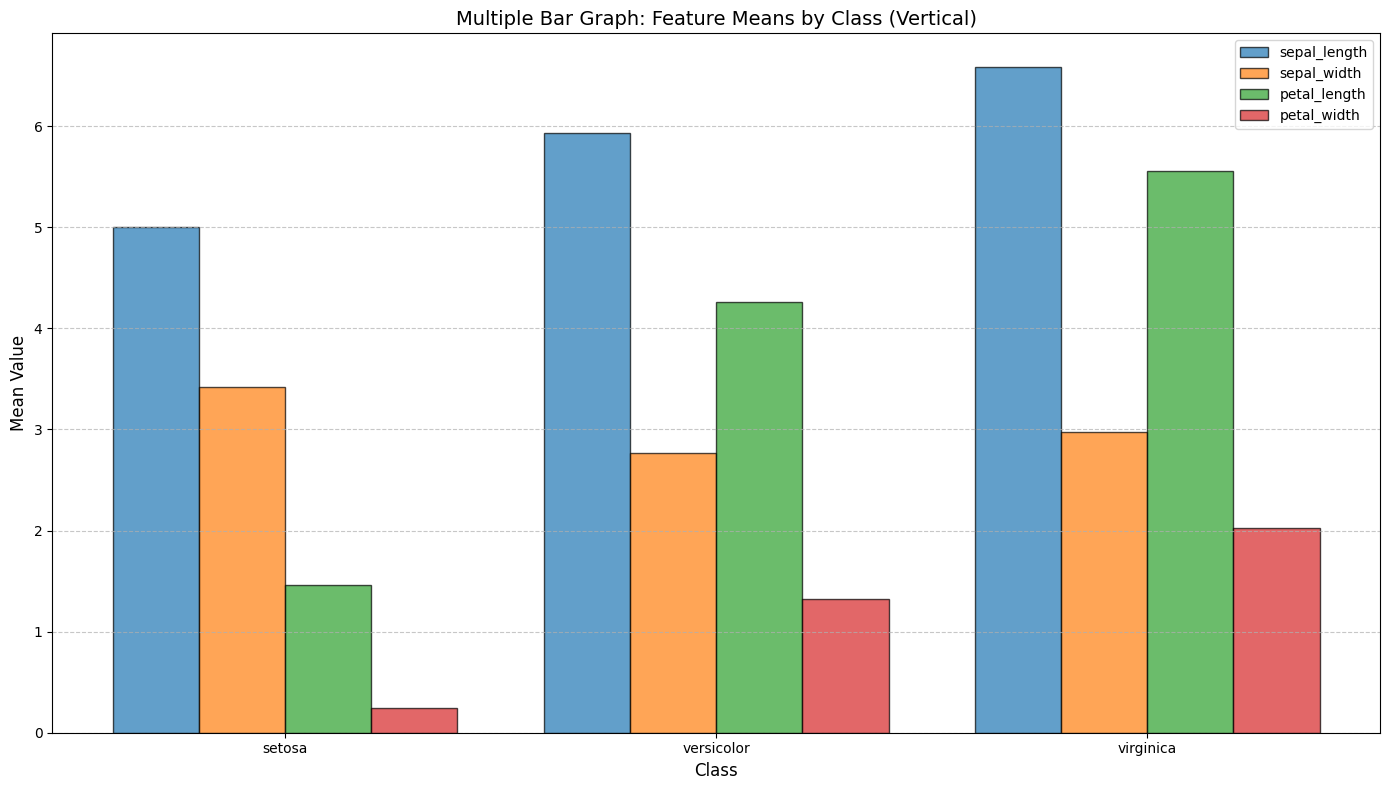

In [26]:
# Cell 23: Multiple bar graph - Feature means by class
if not pd.api.types.is_numeric_dtype(df[class_column]):
    # Calculate mean of each feature for each class
    class_means = df.groupby(class_column)[numeric_columns].mean()
    
    # Set up the plot
    plt.figure(figsize=(14, 8))
    
    # Number of features and classes
    n_features = len(numeric_columns)
    n_classes = len(class_means)
    
    # Width of a bar group
    width = 0.8 / n_features
    
    # Positions of the bars on the x-axis
    indices = np.arange(n_classes)
    
    # Plot bars for each feature
    for i, feature in enumerate(numeric_columns):
        offset = width * i - (width * (n_features - 1) / 2)
        plt.bar(indices + offset, class_means[feature], width=width, label=feature,
               alpha=0.7, edgecolor='black', linewidth=1)
    
    plt.title('Multiple Bar Graph: Feature Means by Class (Vertical)', fontsize=14)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Mean Value', fontsize=12)
    plt.xticks(indices, class_means.index)
    plt.legend(loc='best')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('multiple_bar_graph_vertical.png')
    plt.show()

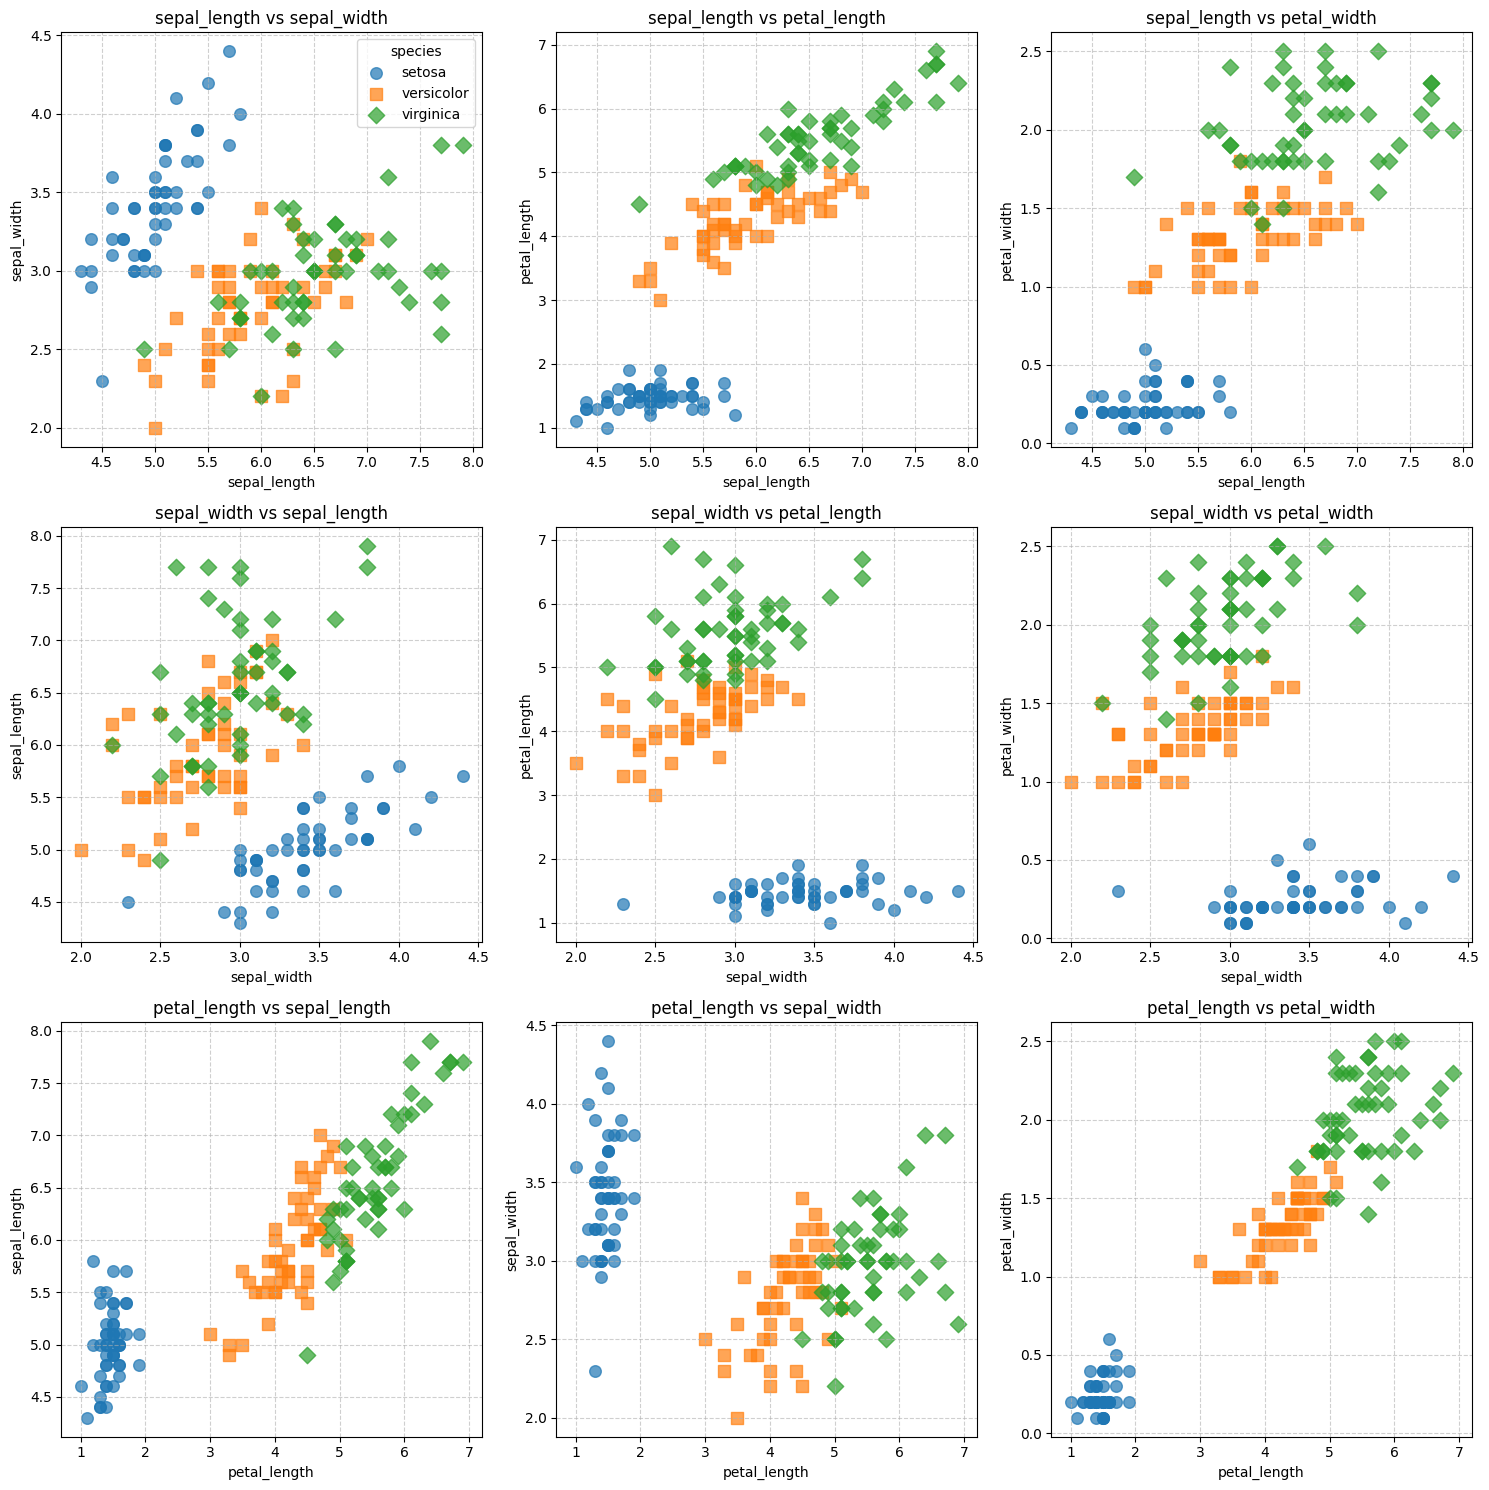

In [27]:
# Cell 24: Scatter charts with varying markers by class
# This cell creates scatter charts with different markers for each class
if len(numeric_columns) >= 2:
    # Create pairs of features for scatter plots
    feature_pairs = [(a, b) for a in numeric_columns for b in numeric_columns if a != b]
    
    # Determine grid size based on number of pairs
    grid_size = min(3, len(feature_pairs))  # Maximum 3x3 grid
    
    plt.figure(figsize=(15, 15))
    
    for i, (feature_x, feature_y) in enumerate(feature_pairs[:grid_size*grid_size]):
        if i < grid_size*grid_size:
            plt.subplot(grid_size, grid_size, i+1)
            
            # If class column exists, use different markers for each class
            if not pd.api.types.is_numeric_dtype(df[class_column]):
                for j, cls in enumerate(df[class_column].unique()):
                    class_data = df[df[class_column] == cls]
                    
                    # Different marker for each class
                    markers = ['o', 's', 'D', '^', 'v', 'p', '*']
                    
                    plt.scatter(
                        class_data[feature_x], 
                        class_data[feature_y],
                        marker=markers[j % len(markers)],
                        s=70,
                        alpha=0.7,
                        label=cls if i == 0 else ""  # Only show legend on first plot
                    )
                
                if i == 0:
                    plt.legend(title=class_column, loc='best')
            else:
                plt.scatter(df[feature_x], df[feature_y], s=70, alpha=0.7)
            
            plt.xlabel(feature_x)
            plt.ylabel(feature_y)
            plt.title(f'{feature_x} vs {feature_y}')
            plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('scatter_matrix_markers.png')
    plt.show()

In [29]:
# Cell 25: Summary and conclusion
# This cell provides a comprehensive summary of the data analysis and visualization
print("\n----- SUMMARY AND CONCLUSION -----")
print("\nIris Dataset Analysis Summary:")

# Dataset overview
print(f"\n1. Dataset Overview:")
print(f"   - Total observations: {len(df)}")
print(f"   - Total features: {len(df.columns)}")
print(f"   - Numeric features: {len(numeric_columns)}")
print(f"   - Target variable: {class_column}")

# Class distribution if applicable
if not pd.api.types.is_numeric_dtype(df[class_column]):
    class_dist = df[class_column].value_counts()
    print(f"\n2. Class Distribution:")
    for cls, count in class_dist.items():
        print(f"   - {cls}: {count} samples ({count/len(df)*100:.1f}%)")

# Feature statistics summary
print(f"\n3. Feature Statistics Summary:")
for feature in numeric_columns:
    print(f"   {feature}:")
    print(f"     - Range: {df[feature].min():.2f} to {df[feature].max():.2f}")
    print(f"     - Mean: {df[feature].mean():.2f}, Median: {df[feature].median():.2f}")
    print(f"     - Standard Deviation: {df[feature].std():.2f}")
    print(f"     - Outliers: {outliers_summary[feature]['count']} ({outliers_summary[feature]['percentage']:.2f}%)")

# Feature correlation
if len(numeric_columns) > 1:
    print(f"\n4. Feature Correlations:")
    high_corr_pairs = []
    for i, feat1 in enumerate(numeric_columns):
        for feat2 in numeric_columns[i+1:]:
            corr = df[feat1].corr(df[feat2])
            if abs(corr) > 0.7:  # Highlighting strong correlations
                high_corr_pairs.append((feat1, feat2, corr))
    
    if high_corr_pairs:
        print("   Strong correlations (|r| > 0.7):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"     - {feat1} and {feat2}: {corr:.3f}")
    else:
        print("   No strong correlations found between features.")

# Main findings
print("\n5. Main Findings:")
print("   - The histograms and boxplots reveal the distributions of each feature.")
print("   - The correlation heatmap shows relationships between numeric features.")
print("   - Outliers were identified using the IQR method.")
print("   - The scatter plot matrix visualizes relationships between pairs of features.")
if not pd.api.types.is_numeric_dtype(df[class_column]):
    print("   - The radar chart compares feature means across different classes.")
    print("   - The 3D scatter plot provides a three-dimensional view of the feature space.")

print("\n6. Conclusion:")
print("   This analysis provides a comprehensive exploration of the Iris dataset,")
print("   including feature distributions, outlier detection, and visualizations")
print("   of relationships between features and classes. The visualizations help")
print("   identify patterns and characteristics that can inform further modeling")
print("   and machine learning approaches.")


----- SUMMARY AND CONCLUSION -----

Iris Dataset Analysis Summary:

1. Dataset Overview:
   - Total observations: 150
   - Total features: 5
   - Numeric features: 4
   - Target variable: species

2. Class Distribution:
   - setosa: 50 samples (33.3%)
   - versicolor: 50 samples (33.3%)
   - virginica: 50 samples (33.3%)

3. Feature Statistics Summary:
   sepal_length:
     - Range: 4.30 to 7.90
     - Mean: 5.84, Median: 5.80
     - Standard Deviation: 0.83
     - Outliers: 0 (0.00%)
   sepal_width:
     - Range: 2.00 to 4.40
     - Mean: 3.05, Median: 3.00
     - Standard Deviation: 0.43
     - Outliers: 4 (2.67%)
   petal_length:
     - Range: 1.00 to 6.90
     - Mean: 3.76, Median: 4.35
     - Standard Deviation: 1.76
     - Outliers: 0 (0.00%)
   petal_width:
     - Range: 0.10 to 2.50
     - Mean: 1.20, Median: 1.30
     - Standard Deviation: 0.76
     - Outliers: 0 (0.00%)

4. Feature Correlations:
   Strong correlations (|r| > 0.7):
     - sepal_length and petal_length: 0.872
